../../zeropod-multipods/DATA/core_6_prioritize_nothing/W5/ppt_32_bppn_320_topk_16/DATA_zeropod_W5_1/core_buffer_counts.txt


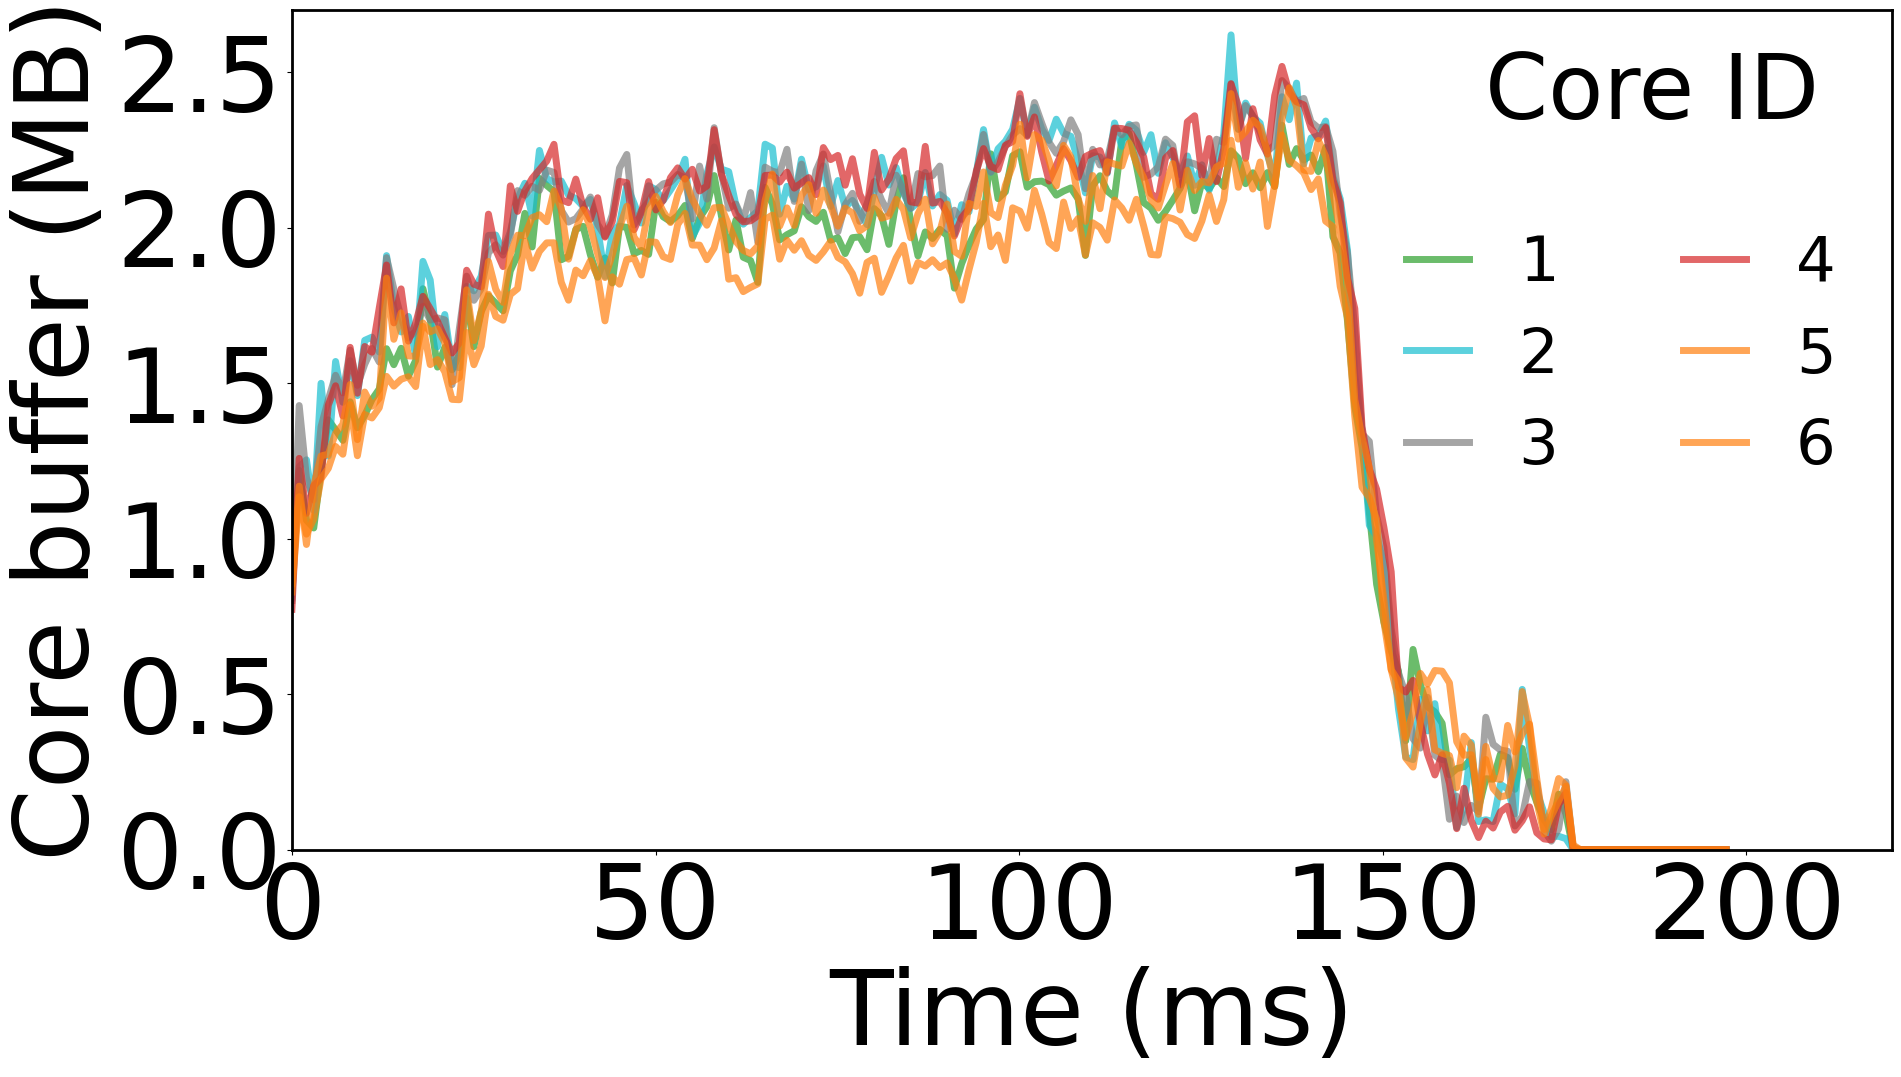

In [1]:
# VLB Incast
import numpy as np
from matplotlib import pyplot as plt


# workloads = ['W4_0.1', 'W4_0.25', 'W4_0.5', 'W4_0.75', 'W4_1']
# workloads = ["incast_degree1", "incast_degree5", "incast_degree10", "incast_degree15", "incast_degree20"]
loads = ['0.1', '0.25', '0.5', '0.75', '1']
loads = ['1']
# loads = ['1']
# workloads = ['W4_1']
# workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100"]
# workloads = ["permutation_size50"]

myfontsize = 75

load = 'Pureincast'
# load = 'Permutation'
show_intervals = [13, 26, 52, 78, 104, 208]
show_intervals = [104]

def find_last_nonzero(arr):
    for i in range(len(arr) - 1, 0, -1):
        if arr[i] > 0.1:
            return i
    return None
# loads = ['1', '3', '10', '30', '100', '300', '1000']

for iii, load in enumerate(loads):
    # Flashpod/zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_supress_c2e_e2p/W5/ppt_32_bppn_320_topk_16
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/select_core_according_to_flow_size_4_6_supress_c2e/W5/ppt_32_bppn_320_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/W5/ppt_32_bppn_20_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/W5/ppt_16_bppn_1280_topk_16/DATA_zeropod_W5_" + load
    dir_name = "../../zeropod-multipods/DATA/core_6_prioritize_nothing/W5/ppt_32_bppn_320_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/new_schedule5_wrong/W5/ppt_32_bppn_320_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/select_core_according_to_flow_size_8_8_supress_c2e/W4_28_lower_ost/ppt_32_bppn_320_topk_16/DATA_zeropod_W4_" + load
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_BPPN_1/DATA_zeropod_W5_" + load
    filename = dir_name + '/core_buffer_counts.txt'
    print(filename)

    # data = np.loadtxt(filename, delimiter=' ', usecols=(0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15))
    data = np.loadtxt(filename, delimiter=' ', usecols=(0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15))
    labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    # 计算每1000行数据的平均值
    n_rows = data.shape[0]  # 数据的行数
    n_cols = data.shape[1]  # 数据的列数
    chunk_size = 1000  # 每块的行数

    # 初始化一个新的数组来存储平均值
    average_data = np.zeros((n_rows // chunk_size + (1 if n_rows % chunk_size != 0 else 0), n_cols))

    # 计算每1000行的平均值
    for i in range(0, n_rows, chunk_size):
        # 计算当前块的结束索引
        end = min(i + chunk_size, n_rows)
        # 计算当前块的平均值并存储到新数组中
        average_data[i // chunk_size] = np.mean(data[i:end], axis=0)
        
    # data = data[::8, :]
    # core_buffer_mean = np.mean(data, axis=1) / 8
    # fig = plt.figure(figsize=(20,12), dpi=200)
    # fig1=plt.subplot(211)
    _, ax = plt.subplots(figsize=(20,12))
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    sample_interval = 1.001 #us
    time_stamp  = np.arange(len(average_data[:,0])) * sample_interval

    # colors = ['darkblue', 'darkgray', 'darkgreen', 'darkcyan', 'darkorange', 'darkmagenta', 'darkgoldenrod', 'darkred', 'darkviolet', 'darkslategray', 'darkturquoise', 'darkolivegreen', 'darkkhaki', 'darkseagreen', 'darkslateblue', 'darkorchid']
    colors = [
    '#2ca02c', '#17becf', '#7f7f7f',
    '#d62728', '#ff7f0e', '#ff7f0e', '#8c564b', '#e377c2',
    '#bcbd22', '#dbdb8d', '#c49c94', '#ff9896',
    '#c5b0d5', '#f7b6d2', '#ffbb78'
    ]
    handles = []
    for core_id in [0,1,2,3,4,5]:
        # plt.scatter(time_stamp/(1000/chunk_size), average_data[:, core_id], s=20, c=colors[core_id], alpha=0.2, label='core={}'.format(core_id))
        # line, = plt.plot(time_stamp/(1000/chunk_size), average_data[:, core_id], c=colors[core_id], linewidth=5, alpha=0.7, label='{}'.format(core_id))
        line, = plt.plot(time_stamp/(1000/chunk_size), average_data[:, core_id]/2/1024, c=colors[core_id], linewidth=5, alpha=0.7, label='{}'.format(core_id))
        handles.append(line)

    # plt.scatter(time_stamp/1000, np.mean(data[:4], axis=1), s=20, c='k', alpha=0.2, label='average')
    


    # 加一条横线，表示一个epoch发的包数量
    # plt.plot((0, time_stamp[-1]), (1953, 1953), linestyle='--', color='k', linewidth=2)

    # plt.xlabel(r"Time ($\mu$s)", fontsize=myfontsize)
    # plt.xlim(10000, 11000)
    plt.xlabel(r"Time ($\mu$s)", fontsize=myfontsize)
    plt.xlabel(r"Time (ms)", fontsize=myfontsize)
    # plt.ylabel("Core buffer\n(#. of packets)", fontsize=myfontsize)
    plt.ylabel("Core buffer (MB)", fontsize=myfontsize)
    # xticks = [0, 100, 200, 300, 400, 500]
    # plt.xticks(xticks, fontsize=myfontsize)

    # yticks = [100, 200, 300, 400]
    # plt.yticks(yticks, fontsize=myfontsize)
    # plt.grid(axis='y')

    # plt.xlim([100,101])
    # ax1 = plt.gca()
    # ax.legend(handles=handles[:1], labels=labels[:1], ncol=1, bbox_to_anchor=(0.95, 0.9), fontsize=myfontsize-10-20, framealpha=0, handlelength=2)
    # ax2 = plt.subplot(1, 1, 1)
    ax2 = ax.twinx()
    ax2.legend(handles=handles[:], labels=labels[:6], ncol=2, bbox_to_anchor=(1, 0.8), fontsize=myfontsize-10-20, framealpha=0, handlelength=1)
    ax2.axis('off')
    # x轴标签加粗
    plt.xticks(fontsize=myfontsize)
    plt.yticks(fontsize=myfontsize)
    ax.tick_params(axis='x', labelsize=myfontsize)
    ax.tick_params(axis='y', labelsize=myfontsize)
    ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
    # ax.set_yticks([0, 1000, 2000, 3000, 4000, 5000], ["0", "1K", "2K", "3K", "4K", "5K"])
    ax.set_xlim([0, 220])
    ax.set_ylim([0, 2.7])
    ax.text(0.85, 0.9, 'Core ID', fontsize=myfontsize-10, horizontalalignment='center',
        verticalalignment='center', transform=ax.transAxes,
        )
    plt.subplots_adjust(left=0.15, right=0.95, bottom=0.2, top=0.9)
    # plt.show()
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/9. Core-Buffer-Against-Time-6-Cores.pdf")


../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/W5/ppt_32_bppn_20_topk_16/DATA_zeropod_W5_1/core_buffer_counts.txt


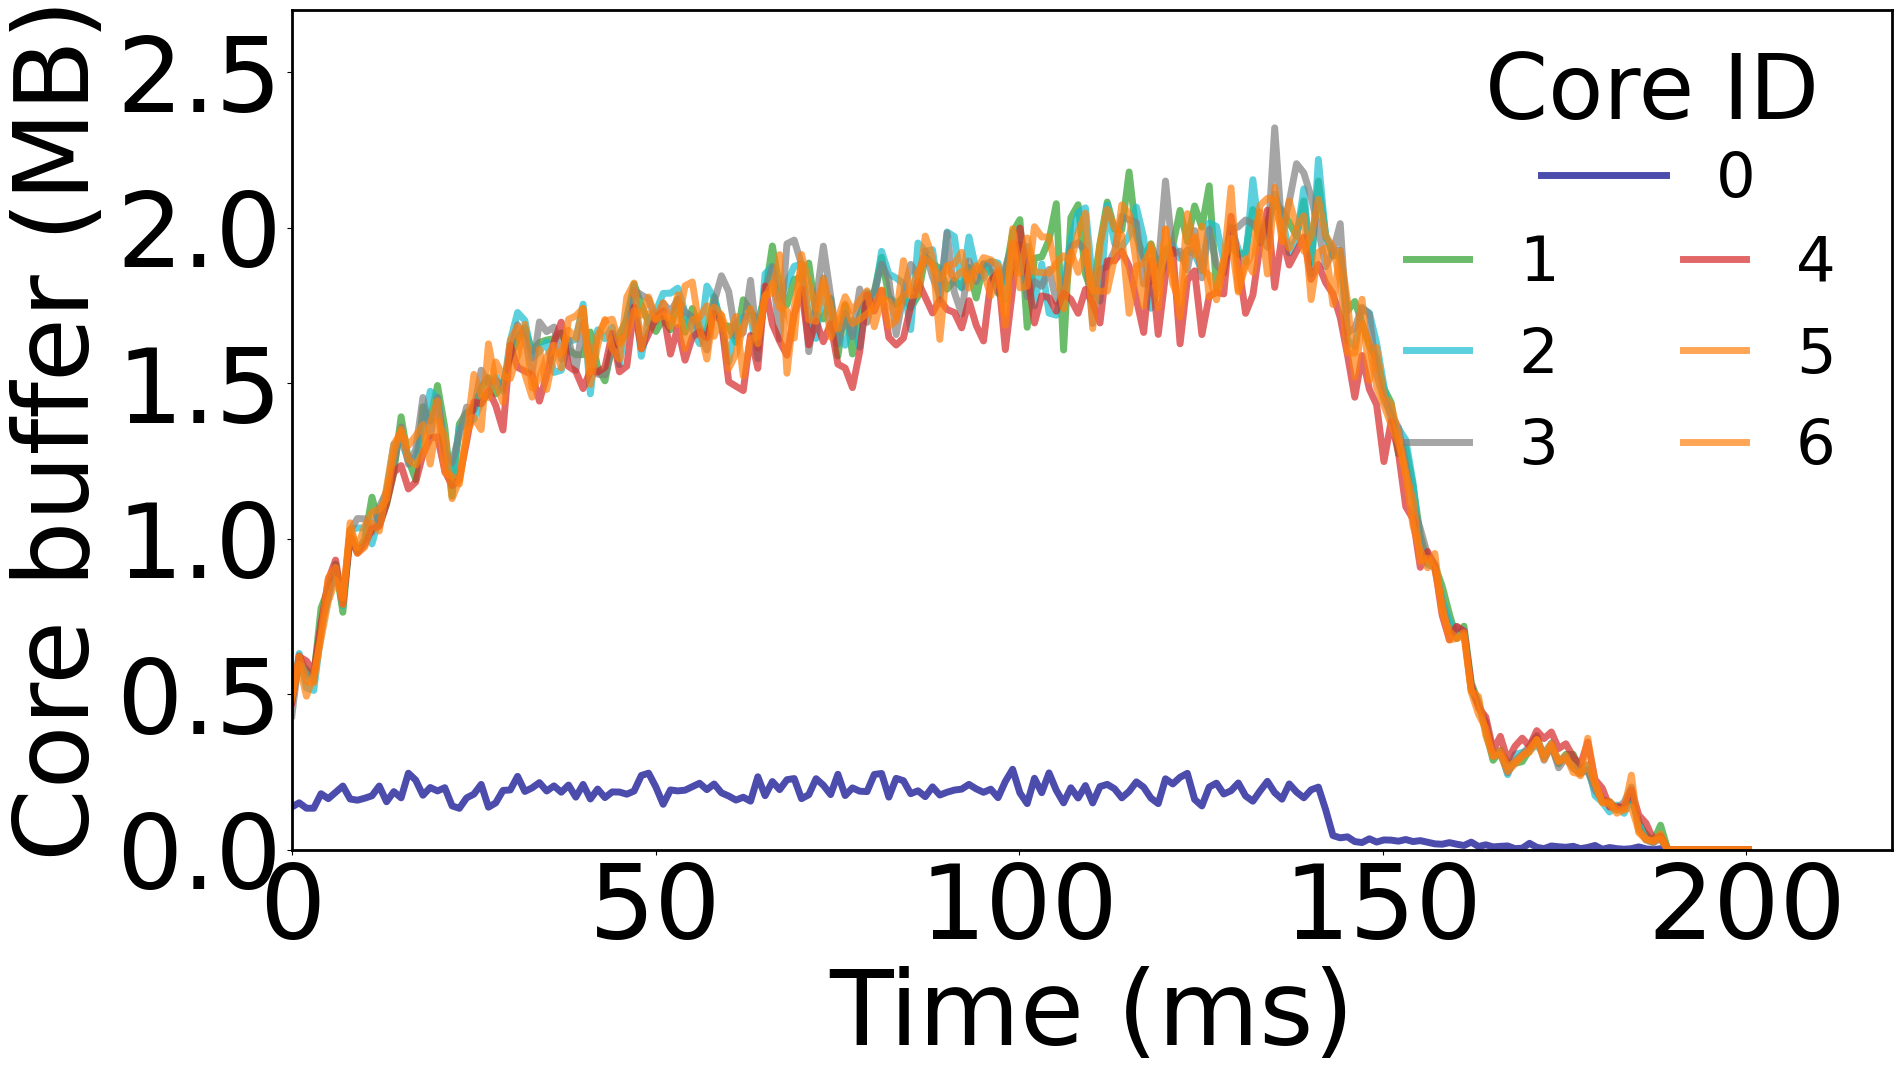

In [2]:
# VLB Incast
import numpy as np
from matplotlib import pyplot as plt


# workloads = ['W4_0.1', 'W4_0.25', 'W4_0.5', 'W4_0.75', 'W4_1']
# workloads = ["incast_degree1", "incast_degree5", "incast_degree10", "incast_degree15", "incast_degree20"]
loads = ['0.1', '0.25', '0.5', '0.75', '1']
loads = ['1']
# loads = ['1']
# workloads = ['W4_1']
# workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100"]
# workloads = ["permutation_size50"]

myfontsize = 75

load = 'Pureincast'
# load = 'Permutation'
show_intervals = [13, 26, 52, 78, 104, 208]
show_intervals = [104]

def find_last_nonzero(arr):
    for i in range(len(arr) - 1, 0, -1):
        if arr[i] > 0.1:
            return i
    return None
# loads = ['1', '3', '10', '30', '100', '300', '1000']

for iii, load in enumerate(loads):
    # Flashpod/zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_supress_c2e_e2p/W5/ppt_32_bppn_320_topk_16
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/select_core_according_to_flow_size_4_6_supress_c2e/W5/ppt_32_bppn_320_topk_16/DATA_zeropod_W5_" + load
    dir_name = "../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/W5/ppt_32_bppn_20_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../../zeropod-multipods/DATA/select_core_according_to_flow_size_1_6_prioritize_e2e/W5/ppt_16_bppn_1280_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../../zeropod-multipods/DATA/core_6_prioritize_nothing/W5/ppt_16_bppn_1280_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/new_schedule5_wrong/W5/ppt_32_bppn_320_topk_16/DATA_zeropod_W5_" + load
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/select_core_according_to_flow_size_8_8_supress_c2e/W4_28_lower_ost/ppt_32_bppn_320_topk_16/DATA_zeropod_W4_" + load
    # dir_name = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_BPPN_1/DATA_zeropod_W5_" + load
    filename = dir_name + '/core_buffer_counts.txt'
    print(filename)

    # data = np.loadtxt(filename, delimiter=' ', usecols=(0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15))
    data = np.loadtxt(filename, delimiter=' ', usecols=(0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15))
    labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    # 计算每1000行数据的平均值
    n_rows = data.shape[0]  # 数据的行数
    n_cols = data.shape[1]  # 数据的列数
    chunk_size = 1000  # 每块的行数

    # 初始化一个新的数组来存储平均值
    average_data = np.zeros((n_rows // chunk_size + (1 if n_rows % chunk_size != 0 else 0), n_cols))

    # 计算每1000行的平均值
    for i in range(0, n_rows, chunk_size):
        # 计算当前块的结束索引
        end = min(i + chunk_size, n_rows)
        # 计算当前块的平均值并存储到新数组中
        average_data[i // chunk_size] = np.mean(data[i:end], axis=0)
        
    # data = data[::8, :]
    # core_buffer_mean = np.mean(data, axis=1) / 8
    # fig = plt.figure(figsize=(20,12), dpi=200)
    # fig1=plt.subplot(211)
    _, ax = plt.subplots(figsize=(20,12))
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    sample_interval = 1.001 #us
    time_stamp  = np.arange(len(average_data[:,0])) * sample_interval

    # colors = ['darkblue', 'darkgray', 'darkgreen', 'darkcyan', 'darkorange', 'darkmagenta', 'darkgoldenrod', 'darkred', 'darkviolet', 'darkslategray', 'darkturquoise', 'darkolivegreen', 'darkkhaki', 'darkseagreen', 'darkslateblue', 'darkorchid']
    colors = [
    'darkblue', '#2ca02c', '#17becf', '#7f7f7f',
    '#d62728', '#ff7f0e', '#ff7f0e', '#8c564b', '#e377c2',
    '#bcbd22', '#dbdb8d', '#c49c94', '#ff9896',
    '#c5b0d5', '#f7b6d2', '#ffbb78'
    ]
    handles = []
    for core_id in range(7):
        # plt.scatter(time_stamp/(1000/chunk_size), average_data[:, core_id], s=20, c=colors[core_id], alpha=0.2, label='core={}'.format(core_id))
        # line, = plt.plot(time_stamp/(1000/chunk_size), average_data[:, core_id], c=colors[core_id], linewidth=5, alpha=0.7, label='{}'.format(core_id))
        line, = plt.plot(time_stamp/(1000/chunk_size), average_data[:, core_id]/2/1024, c=colors[core_id], linewidth=5, alpha=0.7, label='{}'.format(core_id))
        handles.append(line)

    # plt.scatter(time_stamp/1000, np.mean(data[:4], axis=1), s=20, c='k', alpha=0.2, label='average')
    


    # 加一条横线，表示一个epoch发的包数量
    # plt.plot((0, time_stamp[-1]), (1953, 1953), linestyle='--', color='k', linewidth=2)

    # plt.xlabel(r"Time ($\mu$s)", fontsize=myfontsize)
    # plt.xlim(10000, 11000)
    plt.xlabel(r"Time ($\mu$s)", fontsize=myfontsize)
    plt.xlabel(r"Time (ms)", fontsize=myfontsize)
    # plt.ylabel("Core buffer\n(#. of packets)", fontsize=myfontsize)
    plt.ylabel("Core buffer (MB)", fontsize=myfontsize)
    
    # xticks = [0, 100, 200, 300, 400, 500]
    # plt.xticks(xticks, fontsize=myfontsize)

    # yticks = [100, 200, 300, 400]
    # plt.yticks(yticks, fontsize=myfontsize)
    # plt.grid(axis='y')

    # plt.xlim([100,101])
    # ax1 = plt.gca()
    ax.legend(handles=handles[:1], labels=labels[:1], ncol=1, bbox_to_anchor=(0.95, 0.9), fontsize=myfontsize-10-20, framealpha=0, handlelength=2)
    # ax2 = plt.subplot(1, 1, 1)
    ax2 = ax.twinx()
    ax2.legend(handles=handles[1:], labels=labels[1:7], ncol=2, bbox_to_anchor=(1, 0.8), fontsize=myfontsize-10-20, framealpha=0, handlelength=1)
    ax2.axis('off')
    # x轴标签加粗
    plt.xticks(fontsize=myfontsize)
    plt.yticks(fontsize=myfontsize)
    ax.tick_params(axis='x', labelsize=myfontsize)
    ax.tick_params(axis='y', labelsize=myfontsize)
    ax.set_xticks([0, 50, 100, 150, 200])
    ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
    # ax.set_yticks([0, 1000, 2000, 3000, 4000, 5000], ["0", "1K", "2K", "3K", "4K", "5K"])
    # ax.set_yticks([0, 3000, 6000, 9000, 12000], ["0", "3K", "6K", "9K", "12K"])
    ax.set_xlim([0, 220])
    ax.set_ylim([0, 2.7])
    ax.text(0.85, 0.9, 'Core ID', fontsize=myfontsize-10, horizontalalignment='center',
        verticalalignment='center', transform=ax.transAxes,
        )
    plt.subplots_adjust(left=0.15, right=0.95, bottom=0.2, top=0.9)
plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/9. Core-Buffer-Against-Time-6+1-Cores.pdf")